In [10]:
import os
import shutil
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [2]:
import json

# Replace with your username and key
kaggle_json = {
    "username": "labidimahdi",
    "key": "KGAT_cd508928a093f9d98f6e6c791a532e15"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
!kaggle datasets download shreyag1103/brain-mri-scans-for-brain-tumor-classification

Dataset URL: https://www.kaggle.com/datasets/shreyag1103/brain-mri-scans-for-brain-tumor-classification
License(s): unknown
  0% 0.00/24.4M [00:00<?, ?B/s]
100% 24.4M/24.4M [00:00<00:00, 1.63GB/s]


In [4]:
!unzip /content/brain-mri-scans-for-brain-tumor-classification.zip

Archive:  /content/brain-mri-scans-for-brain-tumor-classification.zip
  inflating: data/glioma/Te-glTr_0000.jpg  
  inflating: data/glioma/Te-glTr_0001.jpg  
  inflating: data/glioma/Te-glTr_0002.jpg  
  inflating: data/glioma/Te-glTr_0003.jpg  
  inflating: data/glioma/Te-glTr_0004.jpg  
  inflating: data/glioma/Te-glTr_0005.jpg  
  inflating: data/glioma/Te-glTr_0006.jpg  
  inflating: data/glioma/Te-glTr_0007.jpg  
  inflating: data/glioma/Te-glTr_0008.jpg  
  inflating: data/glioma/Te-glTr_0009.jpg  
  inflating: data/glioma/Te-gl_0010.jpg  
  inflating: data/glioma/Te-gl_0011.jpg  
  inflating: data/glioma/Te-gl_0012.jpg  
  inflating: data/glioma/Te-gl_0013.jpg  
  inflating: data/glioma/Te-gl_0014.jpg  
  inflating: data/glioma/Te-gl_0015.jpg  
  inflating: data/glioma/Te-gl_0016.jpg  
  inflating: data/glioma/Te-gl_0017.jpg  
  inflating: data/glioma/Te-gl_0018.jpg  
  inflating: data/glioma/Te-gl_0019.jpg  
  inflating: data/glioma/Te-gl_0020.jpg  
  inflating: data/glioma/Te-

In [5]:
ORIGINAL_DATA_DIR = './data'
SPLIT_DATA_DIR = './data_split'

TRAIN_DIR = os.path.join(SPLIT_DATA_DIR, 'train')
VAL_DIR = os.path.join(SPLIT_DATA_DIR, 'val')
TEST_DIR = os.path.join(SPLIT_DATA_DIR, 'test')

In [22]:
def create_dataset_splits(source_dir, train_dir, val_dir, test_dir, split_ratio=(0.7, 0.15, 0.15)):
    if not os.path.exists(source_dir):
        print(f"Error: Could not find the source folder: {source_dir}")
        return
    classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]
    print(f"Discovered {len(classes)} classes of tumors.\nSplitting dataset into {split_ratio} (Train, Val, Test)...\n")
    for class_name in classes:
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

        class_folder_path = os.path.join(source_dir, class_name)
        images = os.listdir(class_folder_path)
        random.shuffle(images)

        total_images = len(images)
        train_cut = int(total_images * split_ratio[0])
        val_cut = int(total_images * split_ratio[1])

        train_images = images[:train_cut]
        val_images = images[train_cut : train_cut + val_cut]
        test_images = images[train_cut + val_cut :]

        for img in train_images:
            shutil.copy(os.path.join(class_folder_path, img), os.path.join(train_dir, class_name, img))
        for img in val_images:
            shutil.copy(os.path.join(class_folder_path, img), os.path.join(val_dir, class_name, img)) # Corrected destination
        for img in test_images:
            shutil.copy(os.path.join(class_folder_path, img), os.path.join(test_dir, class_name, img)) # Corrected destination

    print("Success! Images have been split into the robust 'data_split/' directory.")

create_dataset_splits(ORIGINAL_DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR)

Discovered 4 classes of tumors.
Splitting dataset into (0.7, 0.15, 0.15) (Train, Val, Test)...

Success! Images have been split into the robust 'data_split/' directory.


In [7]:
def count_images(split_data_dir):
    for main_split in ['train', 'val', 'test']:
        split_path = os.path.join(split_data_dir, main_split)
        if not os.path.exists(split_path):
            os.makedirs(split_path)
            continue
        print(f"\n--- Output for {main_split.upper()} set ---")
        for disease_folder in os.listdir(split_path):
            disease_path = os.path.join(split_path, disease_folder)
            if os.path.isdir(disease_path):
                image_count = len(os.listdir(disease_path))
                print(f"  > {disease_folder}: {image_count} images")
count_images(SPLIT_DATA_DIR)


--- Output for TRAIN set ---
  > meningioma: 214 images
  > pituitary: 210 images
  > glioma: 210 images
  > notumor: 283 images

--- Output for VAL set ---
  > meningioma: 45 images
  > pituitary: 45 images
  > glioma: 45 images
  > notumor: 60 images

--- Output for TEST set ---
  > meningioma: 47 images
  > pituitary: 45 images
  > glioma: 45 images
  > notumor: 62 images


In [17]:
aug_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    zoom_range=0.3,
    fill_mode='reflect'
)

def augment_directory(directory, aug_datagen, num_augmentations=5, apply_augmentation=True):

    if not apply_augmentation:
        print(f"Skipping augmentation for: {directory}")
        return

    total_generated = 0

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path):
            continue


        original_images = [
            os.path.join(class_path, img)
            for img in os.listdir(class_path)
            if img.endswith('.jpg') and not img.startswith('aug_')
        ]

        print(f"{class_name}: {len(original_images)} original images → generating {len(original_images) * num_augmentations} new images")

        for img_path in original_images:
            img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
            x = tf.keras.utils.img_to_array(img)
            x = x.reshape((1,) + x.shape)

            i = 0
            for batch in aug_datagen.flow(
                x,
                batch_size=1,
                save_to_dir=class_path,
                save_prefix='aug_',
                save_format='png'
            ):
                i += 1
                total_generated += 1
                if i >= num_augmentations:
                    break

    print(f"Done! {total_generated} images generated for: {directory}\n")


augment_directory(TRAIN_DIR, aug_datagen, num_augmentations=5)
augment_directory(VAL_DIR,   aug_datagen, num_augmentations=3)

meningioma: 214 original images → generating 1070 new images
pituitary: 210 original images → generating 1050 new images
glioma: 210 original images → generating 1050 new images
notumor: 283 original images → generating 1415 new images
Done! 4585 images generated for: ./data_split/train

meningioma: 45 original images → generating 135 new images
pituitary: 45 original images → generating 135 new images
glioma: 45 original images → generating 135 new images
notumor: 60 original images → generating 180 new images
Done! 585 images generated for: ./data_split/val



In [18]:
IMG_SIZE = (224, 224)
# We **do NOT** augment the Validation or Test Sets. We want to test the model on normal, un-altered images.
# BATCH SIZE: How many images the AI processes at once before updating its "memory".
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range = 15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [23]:
# LOADING THE IMAGES FROM FOLDERS INTO MEMORY

# Connect the Train Generator to the 'train' folder
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())

Found 5502 images belonging to 4 classes.
Found 943 images belonging to 4 classes.
Found 374 images belonging to 4 classes.


In [27]:
from tensorflow.keras.regularizers import l2

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-3))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
EPOCHS = 15
MODEL_SAVE_PATH = './saved_model/brain_tumor_densenet121.keras'

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

print(f"\n✅ Training concluded! The best version was safely deposited at {MODEL_SAVE_PATH}")

Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 161s 712ms/step - accuracy: 0.6490 - loss: 1.1609 - val_accuracy: 0.8250 - val_loss: 0.6439 - learning_rate: 1.0000e-04
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 85s 495ms/step - accuracy: 0.8301 - loss: 0.6162 - val_accuracy: 0.8770 - val_loss: 0.4886 - learning_rate: 1.0000e-04
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 89s 515ms/step - accuracy: 0.8839 - loss: 0.4652 - val_accuracy: 0.9279 - val_loss: 0.3599 - learning_rate: 1.0000e-04
Epoch 4/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 84s 486ms/step - accuracy: 0.9168 - loss: 0.3640 - val_accuracy: 0.9141 - val_loss: 0.3613 - learning_rate: 1.0000e-04
Epoch 5/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 84s 489ms/step - accuracy: 0.9373 - loss: 0.3120 - val_accuracy: 0.9247 - val_loss: 0.3322 - learning_rate: 1.0000e-04
Epoch 6/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 85s 493ms/step - accuracy: 0.9506 - loss: 0.2687 - val_accuracy: 0.9396 - val_loss: 0.2889 - learning_rate: 1.0000e-04
Epoch 7/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 85s 4

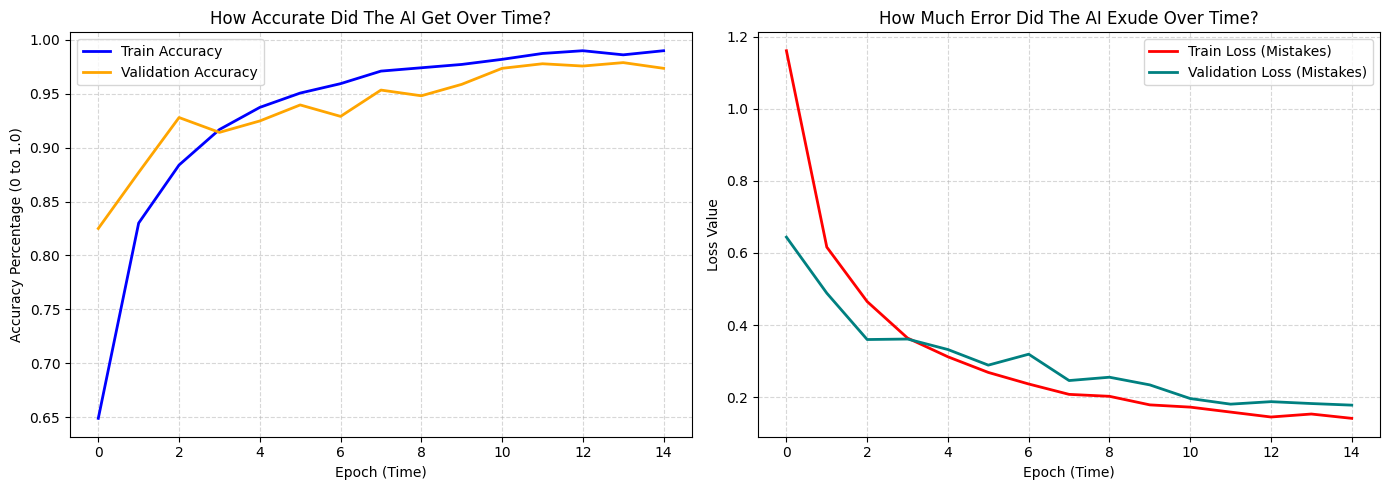

In [29]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', linewidth=2, color='blue')
plt.plot(val_acc, label='Validation Accuracy', linewidth=2, color='orange')
plt.title('How Accurate Did The AI Get Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Accuracy Percentage (0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss (Mistakes)', linewidth=2, color='red')
plt.plot(val_loss, label='Validation Loss (Mistakes)', linewidth=2, color='teal')
plt.title('How Much Error Did The AI Exude Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [30]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"🎯 Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"📉 Final Test Loss/Error: {test_loss:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9893 - loss: 0.1672
🎯 Final Test Accuracy: 98.93%
📉 Final Test Loss/Error: 0.1672


12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step
Average confidence: 98.35%
----------- PREDICTION TEXT REPORT -----------
              precision    recall  f1-score   support

      glioma       0.99      1.00      0.99        85
  meningioma       1.00      0.95      0.98        86
     notumor       0.98      1.00      0.99       118
   pituitary       0.99      1.00      0.99        85

    accuracy                           0.99       374
   macro avg       0.99      0.99      0.99       374
weighted avg       0.99      0.99      0.99       374



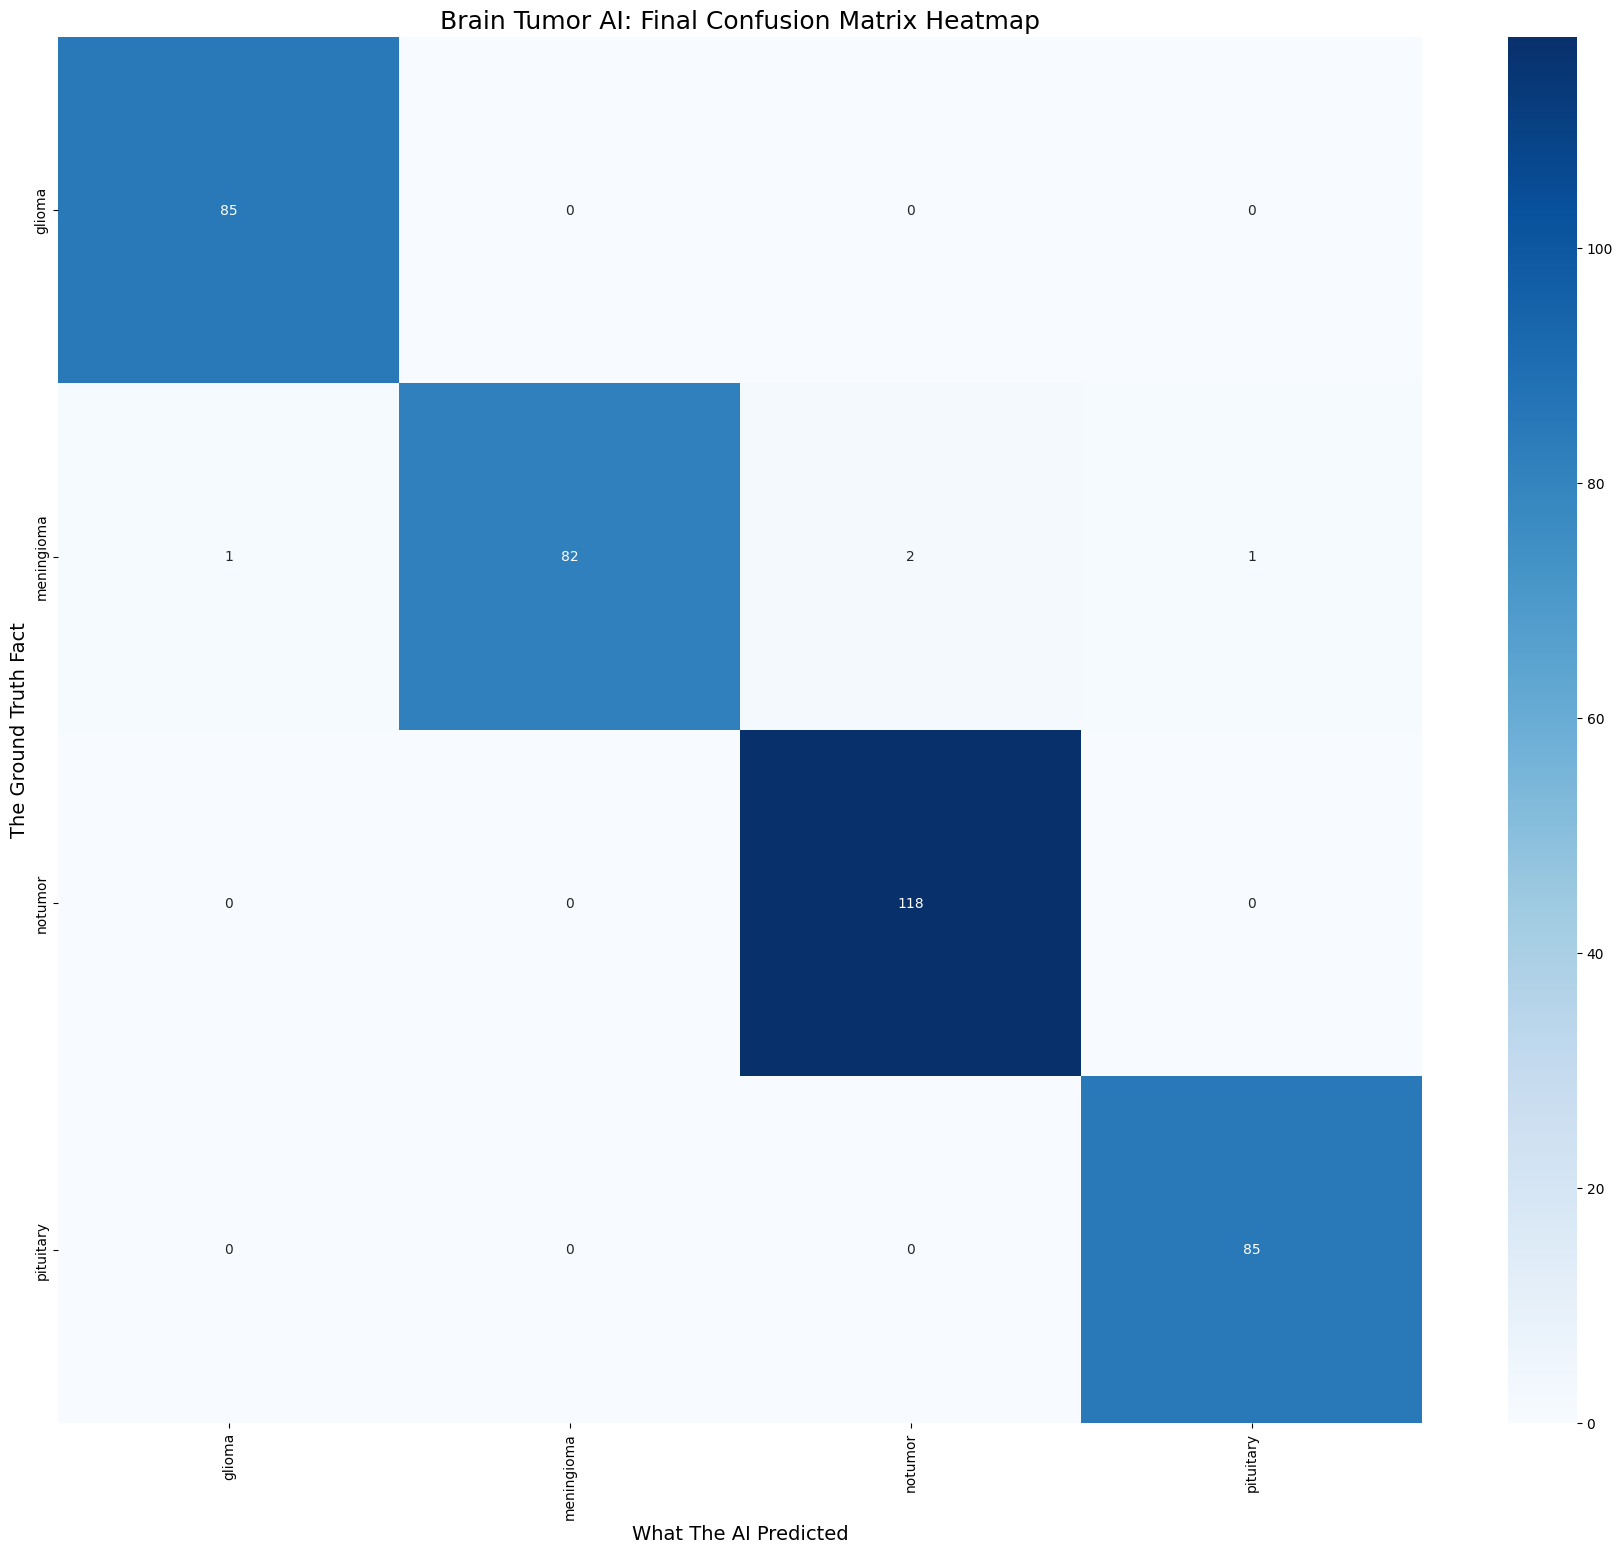

In [31]:
test_generator.reset()

predictions_prob = model.predict(test_generator)

predicted_classes = np.argmax(predictions_prob, axis=1)

true_classes = test_generator.classes

confidence = np.max(predictions_prob, axis=1)
print(f"Average confidence: {confidence.mean():.2%}")

# --- PRINT TEXTUAL REPORT ---
print("----------- PREDICTION TEXT REPORT -----------")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# --- DRAW CONFUSION MATRIX GRAPH ---
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(22, 18))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Brain Tumor AI: Final Confusion Matrix Heatmap', fontsize=18)
plt.xlabel('What The AI Predicted', fontsize=14)
plt.ylabel('The Ground Truth Fact', fontsize=14)
plt.xticks(rotation=90)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


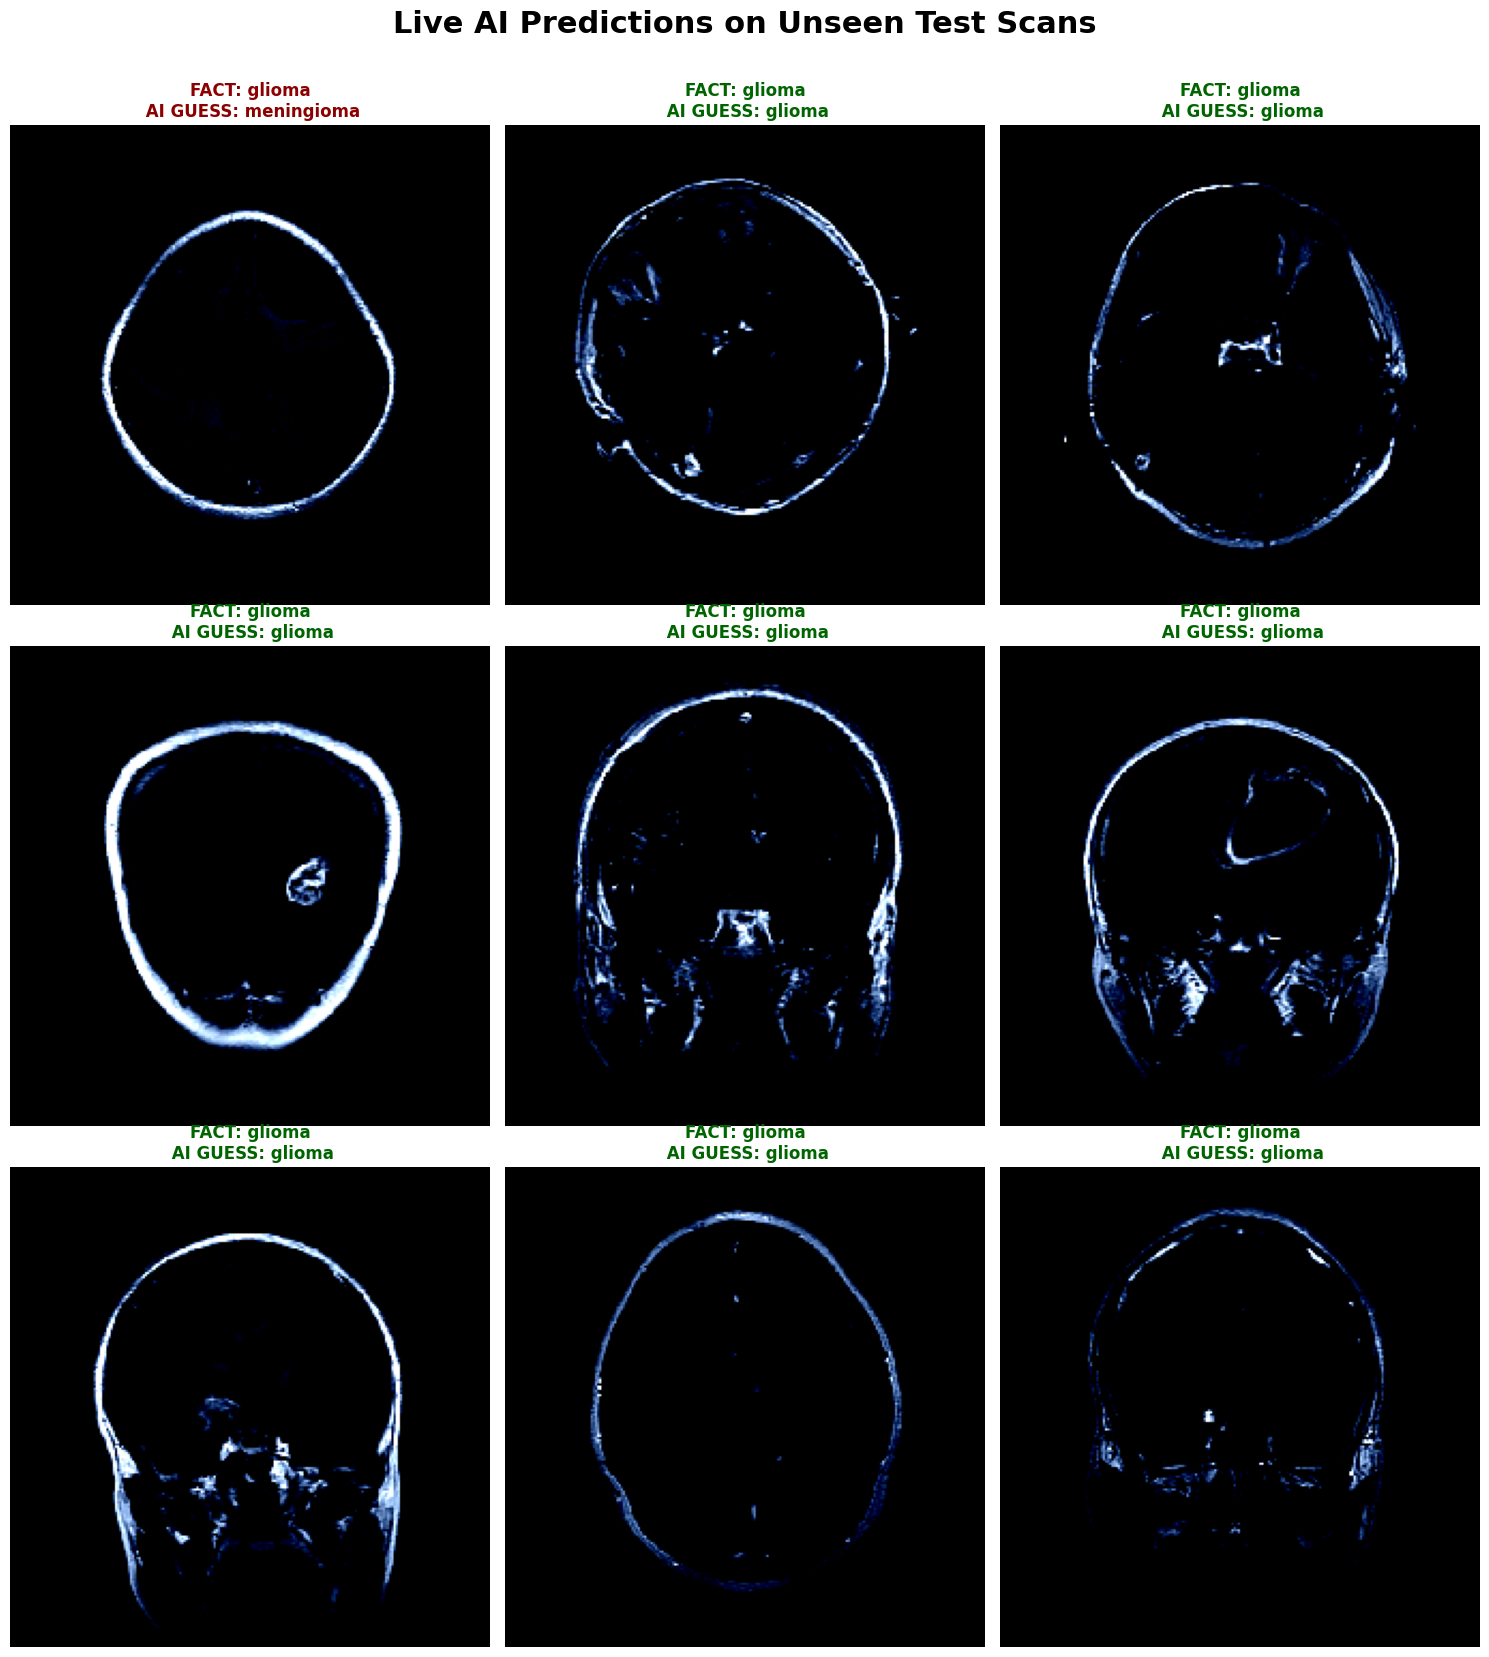

In [ ]:
test_generator.reset()
images, onehot_labels = next(test_generator)

preds = model.predict(images)

pred_ids = np.argmax(preds, axis=1)
true_ids = np.argmax(onehot_labels, axis=1)

fig, axes = plt.subplots(3, 3, figsize=(15, 17))
axes = axes.ravel()

for i in range(25):
    if i < len(images):
        axes[i].imshow(images[i])

        true_name = class_names[true_ids[i]]
        pred_name = class_names[pred_ids[i]]

        text_color = "darkgreen" if true_ids[i] == pred_ids[i] else "darkred"

        axes[i].set_title(f"FACT: {true_name}\n AI GUESS: {pred_name}", color=text_color, fontweight="bold", fontsize=12)
        axes[i].axis('off') # Hide graph axes borders

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle('Live AI Predictions on Unseen Test Scans', fontsize=22, fontweight='bold')
plt.show()